# DTU Course on "Data-driven methods for computational science and engineering" 2025

This notebook is a part of exercises in the DTU Course that complement the lecture. 

To make sure your environment is setup to perform the exercises.

Please report any errors or issues with the materials to Allan Peter Engsig-Karup (apek@dtu.dk).

### Python modules needed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import platform

import time
import torch.nn.functional as F
from torch.nn.parameter import Parameter
import torch.nn.init as init

### Detect device

In [2]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Check for ARM architecture
architecture = platform.machine()
if 'arm' in architecture or 'aarch' in architecture:
    print("Architecture: ARM")
else:
    print(f"Architecture: {architecture}")

# Optional: More detailed GPU check
if device == "cuda":
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# Check for CPU information
cpu_info = platform.processor()
if cpu_info:
    print(f"CPU: {cpu_info}")
else:
    print("CPU information not available.")


Device: cpu
Architecture: ARM
CPU: arm


### Define Precision used in PyTorch

In [3]:
# Set default tensor type in PyTorch to float64 precision
torch.set_default_dtype(torch.float32)

### Define seed for deterministic (reproducible) calculations while testing

In [4]:
# for reproducibility, define a seed manually
seed = 28 # 21 # 13
torch.manual_seed(seed)
np.random.seed(seed)

# The Deep Operator Network (DeepONet)

The DeepONet can be used for operator approximation. Given a function $u$ and a point $y$, we would like to know $G(u)(y)$, where $G$ is an operator.

The DeepONet consists of two networks. The branch network takes as input the discretized function. The trunk network takes as input the points $y$ in which to evaulate $G(u)$. The output dimensions of the two networks are equal, and the final output of the DeepONet is the dot product of these two outputs.


### Learning the antiderivative operator
As an example, we consider the antiderivative operator. In this case we want to provide a function and a point such that the output is the antiderivative of the function evaulated in the point.

The example and data set is borrowed from https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html


In [5]:
# Data size constants
_SENSORS = 100
_NUM_POINTS = 100
_POINT_DIM = 1
_TRAIN_SIZE = 150
_TEST_SIZE = 1000

# Network size
BRANCH_HIDDEN = 40
BRANCH_OUT = 40
TRUNK_HIDDEN = 40
TRUNK_OUT = 40


### Loading the data set

The data set can be found via https://deepxde.readthedocs.io/en/latest/demos/operator/antiderivative_aligned.html at https://yaleedu-my.sharepoint.com/personal/lu_lu_yale_edu/_layouts/15/onedrive.aspx?id=%2Fpersonal%2Flu%5Flu%5Fyale%5Fedu%2FDocuments%2Fdatasets%2Fdeepxde&ga=1

In [11]:
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32, device=device)

def to_numpy(arr):
    return arr.detach().cpu().numpy()

# Load data set
data_train = np.load("./data/deeponet_antiderivative_aligned/antiderivative_aligned_train.npz", allow_pickle=True)
data_test = np.load("./data/deeponet_antiderivative_aligned/antiderivative_aligned_test.npz", allow_pickle=True)
X_train, y_train = (to_tensor(data_train["X"][0]), to_tensor(data_train["X"][1])), to_tensor(data_train["y"])
X_test, y_test = (to_tensor(data_test["X"][0]), to_tensor(data_test["X"][1])), to_tensor(data_test["y"])

print("Training data shapes:")
print("Branch input:  ", X_train[0].shape)
print("Trunk input:   ", X_train[1].shape)
print("Output:        ", y_train.shape)

print("\nTest data shapes:")
print("Branch input:  ", X_test[0].shape)
print("Trunk input:   ", X_test[1].shape)
print("Output:        ", y_test.shape)

Training data shapes:
Branch input:   torch.Size([150, 100])
Trunk input:    torch.Size([100, 1])
Output:         torch.Size([150, 100])

Test data shapes:
Branch input:   torch.Size([1000, 100])
Trunk input:    torch.Size([100, 1])
Output:         torch.Size([1000, 100])


We may also just generate the data ourselves...

In [12]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.spatial.distance import cdist

def generate_grf_antiderivative_data(num_samples=150, num_points=100, length_scale=0.2, seed=None):
    """
    Generate (v(x), u(x)) pairs by sampling v from a Gaussian random field (GRF)
    and computing u(x) = ∫ v(x) dx with u(0) = 0.
    
    Args:
        num_samples (int): Number of samples to generate.
        num_points (int): Number of spatial grid points (resolution of v(x), u(x)).
        length_scale (float): Length scale parameter for the GRF kernel.
        seed (int or None): Seed for reproducibility.
        
    Returns:
        x_grid: 1D numpy array of grid points in [0, 1].
        v_data: (num_samples, num_points) array of v(x) samples.
        u_data: (num_samples, num_points) array of corresponding u(x).
    """
    if seed is not None:
        np.random.seed(seed)

    # Uniform grid over [0, 1]
    x_grid = np.linspace(0, 1, num_points)
    
    # Create the squared exponential kernel (RBF kernel)
    dists = cdist(x_grid[:, None], x_grid[:, None], 'euclidean')
    kernel = np.exp(-0.5 * (dists / length_scale) ** 2)

    # Sample v(x) from multivariate normal with this kernel as covariance
    v_data = np.random.multivariate_normal(mean=np.zeros(num_points), cov=kernel, size=num_samples)

    # Compute u(x) = integral of v(x) using cumulative trapezoidal rule
    u_data = np.array([cumulative_trapezoid(v, x_grid, initial=0.0) for v in v_data])

    return x_grid, v_data, u_data


In [13]:
# Generate data
x, v_samples, u_samples = generate_grf_antiderivative_data(num_samples=150, seed=42)

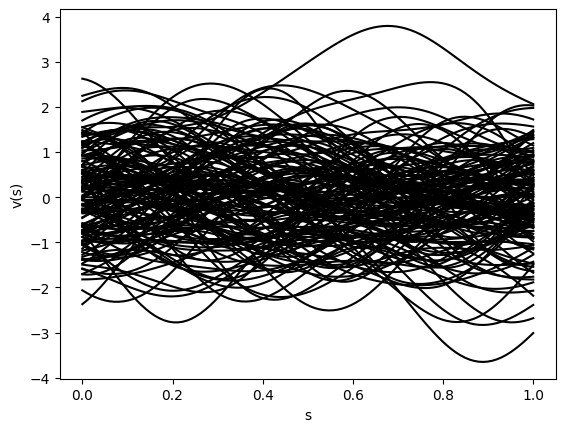

In [14]:
# plot the Gaussian Field functions sampled i the data set
for i in range(v_samples.shape[0]):
    y = v_samples[i]
    plt.plot(x, y,'k')
plt.xlabel('s')
plt.ylabel('v(s)')
plt.show()

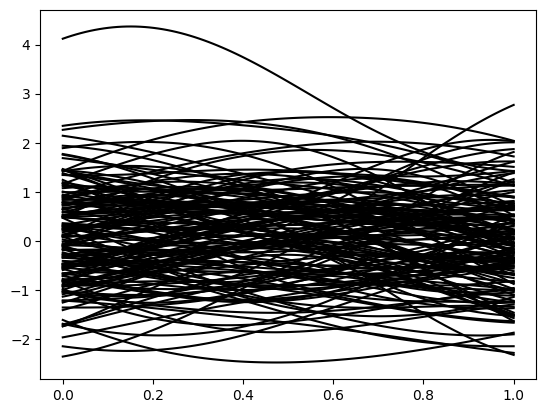

In [15]:
if 0:
    plt.plot(X_train[1].cpu().numpy(),X_train[0][ALL,:].cpu().numpy(),'ro')
    plt.show()
    x = X_train[1].cpu().numpy()
else:
    X_train[0].values = v_samples
    X_train[1].values = x
    y_train.values = u_samples
    for i in range(X_train[0].shape[0]):
        y = X_train[0][i].cpu().numpy()
        plt.plot(x, y,'k')
plt.show()



### Setting up the branch and trunk networks

In [16]:


class BranchNet(nn.Module):
    # Network used to learn from input function

    def __init__(self, num_features, num_hidden, num_output):
        super(BranchNet, self).__init__()

        # Parameters of each layer
        self.W_1 = Parameter(init.xavier_normal_(torch.Tensor(num_hidden[0], num_features)))
        self.b_1 = Parameter(init.constant_(torch.Tensor(num_hidden[0]), 0))

        self.W_2 = Parameter(init.xavier_normal_(torch.Tensor(num_hidden[1], num_hidden[0])))
        self.b_2 = Parameter(init.constant_(torch.Tensor(num_hidden[1]), 0))

        self.W_3 = Parameter(init.xavier_normal_(torch.Tensor(num_output, num_hidden[1])))
        self.b_3 = Parameter(init.constant_(torch.Tensor(num_output), 0))

        self.activation = torch.nn.Tanh()

    def forward(self, x):
        x = F.linear(x, self.W_1, self.b_1)
        x = self.activation(x)
        x = F.linear(x, self.W_2, self.b_2)
        x = self.activation(x)
        x = F.linear(x, self.W_3, self.b_3)
        return x


class TrunkNet(nn.Module):
    # Network used to process coordinates

    def __init__(self, num_features, num_hidden, num_output):
        super(TrunkNet, self).__init__()

        # Parameters of each layer

        self.W_1 = Parameter(init.xavier_normal_(torch.Tensor(num_hidden[0], num_features)))
        self.b_1 = Parameter(init.constant_(torch.Tensor(num_hidden[0]), 0))

        self.W_2 = Parameter(init.xavier_normal_(torch.Tensor(num_hidden[1], num_hidden[0])))
        self.b_2 = Parameter(init.constant_(torch.Tensor(num_hidden[1]), 0))

        self.W_3 = Parameter(init.xavier_normal_(torch.Tensor(num_output, num_hidden[1])))
        self.b_3 = Parameter(init.constant_(torch.Tensor(num_output), 0))

        self.activation = torch.nn.Tanh()

    def forward(self, x):
        x = F.linear(x, self.W_1, self.b_1)
        x = self.activation(x)
        x = F.linear(x, self.W_2, self.b_2)
        x = self.activation(x)
        x = F.linear(x, self.W_3, self.b_3)
        x = self.activation(x) # Post-activation
        return x


# Define the two networks
branch = BranchNet(_SENSORS, [BRANCH_HIDDEN, BRANCH_HIDDEN], BRANCH_OUT).to(device)
trunk = TrunkNet(_POINT_DIM, [TRUNK_HIDDEN,  TRUNK_HIDDEN],  TRUNK_OUT ).to(device)

# The DeepONet output is a dot product of the branch and trunk outputs
def DeepONet(v, x):
    # Dot product of branch and trunk outputs
    return torch.sum(branch(v)*trunk(x), dim=-1)

# Define the loss function
mse = torch.nn.MSELoss()
params = list(branch.parameters()) + list(trunk.parameters())



### Preparing training

In [17]:
EPOCHS = [1000, 1000]
LEARNING_RATES = [1e-3, 5e-4]
losses = []

print_every = 100
batch_size = 1000
unique_train_samples = _TRAIN_SIZE*_NUM_POINTS

num_batches = unique_train_samples // batch_size

branch.train()
trunk.train()


TrunkNet(
  (activation): Tanh()
)

### Training the model

In [18]:
for LR, num_epochs in zip(LEARNING_RATES, EPOCHS):

    optimizer = torch.optim.Adam(params, lr=LR)
    print("\nUsing learning rate: ", LR)
    time_start = time.perf_counter()

    for epoch in range(num_epochs):

        losssave = 0
        idx = torch.randperm(unique_train_samples)

        for i in range(num_batches):

            # Calculate indices
            ii = idx[i*batch_size:(i+1)*batch_size]
            branch_idx = ii // _NUM_POINTS
            trunk_idx = ii % _NUM_POINTS

            # Get data from indices
            v_batch = X_train[0][branch_idx]
            x_batch = X_train[1][trunk_idx]
            u_batch = y_train.ravel()[ii]

            # DeepONet prediction
            d_batch = DeepONet(v_batch, x_batch)

            # Calculate loss
            loss = mse(u_batch, d_batch)

            # Optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losssave += loss

        losses.append(float(losssave / num_batches))


        if (epoch+1) % print_every == 0:
            print("Epoch %4i:   Train Loss = %2.2e" % (
					epoch+1, losses[-1]))
    print("Time:", time.perf_counter()-time_start, "seconds")



Using learning rate:  0.001


/var/folders/4f/7kcbgj992s5fhk7wcryyv4hc0000gn/T/ipykernel_34000/2899853454.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  losses.append(float(losssave / num_batches))


Epoch  100:   Train Loss = 6.87e-04
Epoch  200:   Train Loss = 3.90e-04
Epoch  300:   Train Loss = 2.46e-04
Epoch  400:   Train Loss = 7.64e-05
Epoch  500:   Train Loss = 8.98e-05
Epoch  600:   Train Loss = 1.80e-04
Epoch  700:   Train Loss = 4.24e-05
Epoch  800:   Train Loss = 1.84e-04
Epoch  900:   Train Loss = 4.64e-05
Epoch 1000:   Train Loss = 2.62e-05
Time: 51.82898212480359 seconds

Using learning rate:  0.0005
Epoch  100:   Train Loss = 2.04e-05
Epoch  200:   Train Loss = 8.13e-05
Epoch  300:   Train Loss = 3.48e-05
Epoch  400:   Train Loss = 1.61e-05
Epoch  500:   Train Loss = 2.70e-05
Epoch  600:   Train Loss = 2.63e-05
Epoch  700:   Train Loss = 3.02e-05
Epoch  800:   Train Loss = 8.18e-06
Epoch  900:   Train Loss = 1.59e-05
Epoch 1000:   Train Loss = 9.55e-06
Time: 50.35891383304261 seconds


### Evaluating the model

In [19]:
# Evaulate model
branch.eval()
trunk.eval()
predictions = np.array([to_numpy(DeepONet(X_test[0][i], X_test[1])) for i in range(_TEST_SIZE)])
print("Test MSE: %2.2e" % np.mean(np.square(predictions-to_numpy(y_test))))

Test MSE: 9.19e-05


### Plotting test samples

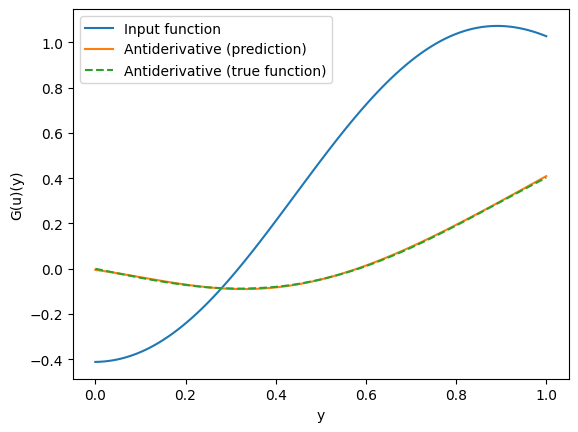

In [20]:
# Choose random test index for plotting
IDX = 100

y_pred = DeepONet(X_test[0][IDX], X_test[1])
plt.plot(to_numpy(X_test[1]), to_numpy(X_test[0][IDX]))
plt.plot(to_numpy(X_test[1]), to_numpy(y_pred))
plt.plot(to_numpy(X_test[1]), to_numpy(y_test[IDX]), linestyle="--")
plt.legend(["Input function", "Antiderivative (prediction)", "Antiderivative (true function)"])
plt.xlabel('y')
plt.ylabel('G(u)(y)')
plt.show()
